In [14]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from scipy.integrate import solve_ivp

In [6]:
ROOT = Path('/home/jorge-linux/GitHub/observatory_benchmark')
DRAG_VALUES = [0.01, 0.1, 1]

COLORS = {
    'PhysiCell': '#4daf4a',  # Green
    'BioDynaMo': '#ff7f00',  # Orange
    'Chaste':    '#377eb8',  # Blue
    'TiSim':     '#984ea3',  # Purple
    'CompuTiX':  '#fd2a2a',  # Pink
}

def drag_str(drag):
    """Return the folder-name string for a given drag value."""
    return '1' if drag == 1 else str(drag)

In [7]:
# ── Analytical reference from two_cell_relaxation_extended_hertz_reference.ipynb
MICROMETER_TO_METER = 1e-6
R_i = 5.0 * MICROMETER_TO_METER   # m
R_j = 5.0 * MICROMETER_TO_METER   # m
E_tilde = 268.0                    # Pa  (composite Young modulus)
gamma   = 8.56e-15                  # J/m^2  (adhesion energy density, sigma=1e15 m^-2)
R_tilde = 1.0 / (1.0/R_i + 1.0/R_j)

# Initial overlap: d0 = 9 µm  =>  delta0 = Ri + Rj - d0 = 1 µm
delta_0_um = 1.0

# Equilibrium overlap: F_eHertz(delta_eq) = 0  =>  delta_eq = (3*pi*gamma*sqrt(R_tilde) / (4*E_tilde))^(2/3)
delta_eq_um = (
    (3.0 * np.pi * gamma * np.sqrt(R_tilde)) / (4.0 * E_tilde)
) ** (2.0 / 3.0) / MICROMETER_TO_METER

print(f'Analytical initial overlap   delta_0  = {delta_0_um:.4f} µm')
print(f'Analytical equilibrium overlap delta_eq = {delta_eq_um:.4f} µm')

Analytical initial overlap   delta_0  = 1.0000 µm
Analytical equilibrium overlap delta_eq = 0.0000 µm


In [8]:
# ── Data loading functions ─────────────────────────────────────────────
# Time unit conventions (all converted to seconds):
#   BioDynaMo  -> minutes  => x60
#   PhysiCell  -> minutes  => x60
#   Chaste     -> seconds  (drag=1 only)
#   TiSim      -> seconds
#   CompuTiX   -> seconds

def load_biodynamo(drag):
    path = ROOT / 'Biodynamo' / 'mechanics_hertz_relaxation' / f'results_drag_{drag_str(drag)}' / 'positions.csv'
    df = pd.read_csv(path, sep=r'\t|,', header=None, engine='python')
    time     = df[0].to_numpy() * 60.0           # minutes -> seconds
    distance = (df[4] - df[1]).abs().to_numpy()  # µm
    overlap  = np.maximum(0.0, 10.0 - distance)
    return time, overlap

def load_chaste():
    """Chaste has a single dataset (corresponds to drag = 1)."""
    path = ROOT / 'Chaste' / 'HertzCellRelaxation' / 'node_locations.dat'
    df = pd.read_csv(path, sep=r'\s+', header=None)
    time     = df[0].to_numpy()                        # seconds
    distance = (df[4] - df[1]).abs().to_numpy() * 1e6  # m -> µm
    overlap  = np.maximum(0.0, 10.0 - distance)
    return time, overlap

def load_computix(drag):
    path = ROOT / 'CompuTiX' / 'overlap_relaxation' / f'results_mu_{drag_str(drag)}.yaml'
    with open(path) as f:
        ctix = yaml.safe_load(f)
    time      = np.array(ctix['t']['values'])                   # seconds
    positions = np.array(ctix['Cells']['values']['x']['values'])
    distance  = np.abs(positions[:, 1] - positions[:, 0]) * 1e6  # m -> µm
    overlap   = np.maximum(0.0, 10.0 - distance)
    return time, overlap

def load_physicell(drag):
    path = ROOT / 'PhysiCell' / 'results' / 'mechanics_pushing_extended_hertz' / f'results_drag_{drag_str(drag)}' / 'physicell_mechanics_pushing_extended_hertz.csv'
    df = pd.read_csv(path)
    time     = df['time_min'].to_numpy() * 60.0  # minutes -> seconds
    distance = df['distance_um'].to_numpy()
    overlap  = df['overlap_um'].to_numpy()
    return time, overlap

def load_tisim(drag):
    path = ROOT / 'Tisim' / 'mechanics_relaxation' / f'data_drag_{drag_str(drag)}.csv'
    df = pd.read_csv(path)
    time     = df['time_s'].to_numpy()               # seconds
    distance = df['distance_10um'].to_numpy() * 10.0  # -> µm
    overlap  = np.maximum(0.0, 10.0 - distance)
    return time, overlap

In [9]:
# ── Load all data ──────────────────────────────────────────────────────
data = {}   # data[drag][simulator] = {'time', 'velocity', 'overlap'}

chaste_time, chaste_ovlp = load_chaste()

for drag in DRAG_VALUES:
    data[drag] = {}
    for name, loader in [
        ('BioDynaMo', load_biodynamo),
        ('PhysiCell', load_physicell),
        ('TiSim',     load_tisim),
        ('CompuTiX',  load_computix),
    ]:
        try:
            t, o = loader(drag)
            data[drag][name] = {'time': t, 'overlap': o}
        except Exception as e:
            print(f'  [{name}, drag={drag}] skipped: {e}')

    # Chaste only available for drag = 1
    if drag == 1:
        data[drag]['Chaste'] = {'time': chaste_time, 'overlap': chaste_ovlp}

print('Data loaded successfully.')

Data loaded successfully.


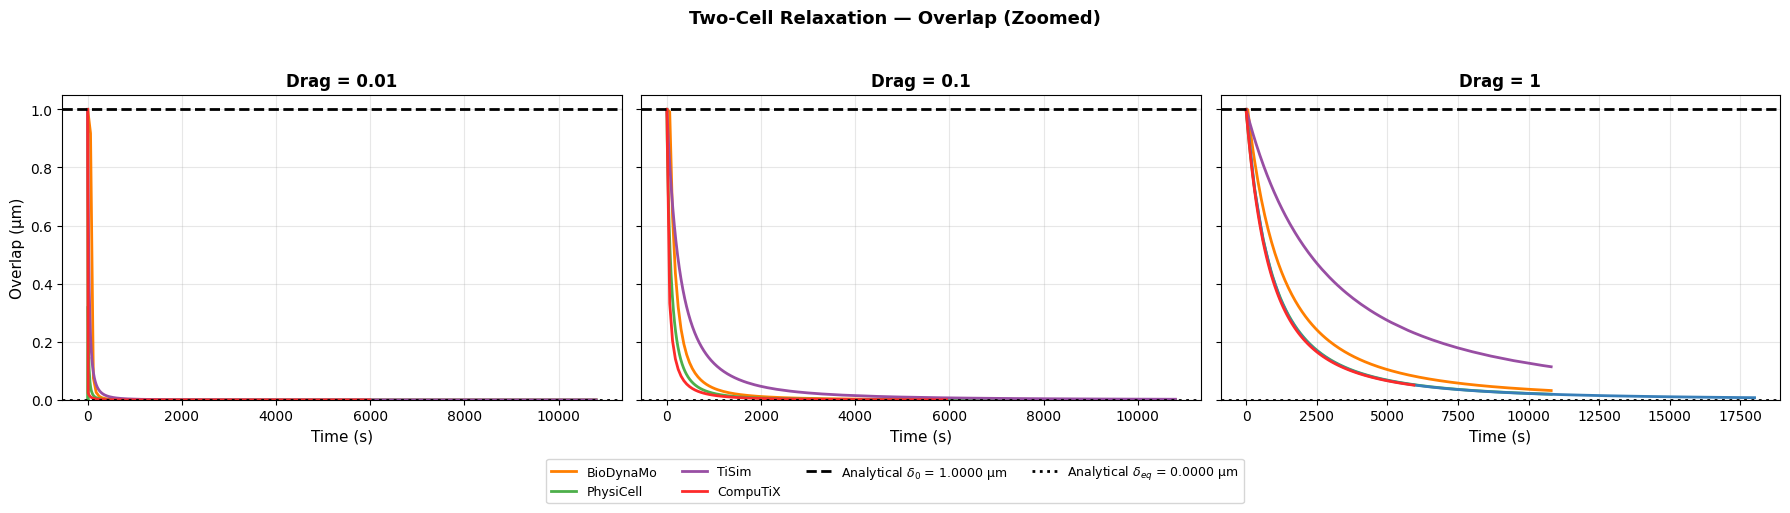

In [10]:
# ── One figure with three panels: one panel per drag value ──────────────

SIM_ORDER = ['BioDynaMo', 'PhysiCell', 'Chaste', 'TiSim', 'CompuTiX']
T_MAX = 1000  # seconds

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

fig.suptitle(
    'Two-Cell Relaxation — Overlap (Zoomed)',
    fontsize=13,
    fontweight='bold'
)

for ax, drag in zip(axes, DRAG_VALUES):

    for sim in SIM_ORDER:
        if sim not in data[drag]:
            continue

        d_plot = data[drag][sim]
        # d_plot = d[d['time'] <= T_MAX]

        kw = dict(
            color=COLORS[sim],
            lw=2,
            label=sim
        )

        ax.plot(
            d_plot['time'],
            d_plot['overlap'],
            **kw
        )

    # Analytical reference lines
    ax.axhline(
        delta_0_um,
        color='black',
        lw=2,
        ls='--',
        label=f'Analytical $\\delta_0$ = {delta_0_um:.4f} µm'
    )

    ax.axhline(
        delta_eq_um,
        color='black',
        lw=2,
        ls=':',
        label=f'Analytical $\\delta_{{eq}}$ = {delta_eq_um:.4f} µm'
    )

    ax.set_title(
        f'Drag = {drag}',
        fontsize=12,
        fontweight='bold'
    )

    ax.set_xlabel('Time (s)', fontsize=11)
    ax.set_ylim(bottom=0)
    ax.grid(alpha=0.3)

axes[0].set_ylabel('Overlap (µm)', fontsize=11)

# Single legend for all panels
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.02),
    ncol=4,
    fontsize=9
)

plt.tight_layout(rect=[0, 0.08, 1, 0.95])

out = (
    ROOT
    / 'ResultAnalysis'
    / 'plots'
    / 'mechanics_pushing_extended_hertz'
    / f'mechanics_pushing_extended_hertz_all_drags.png'
)

# plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()

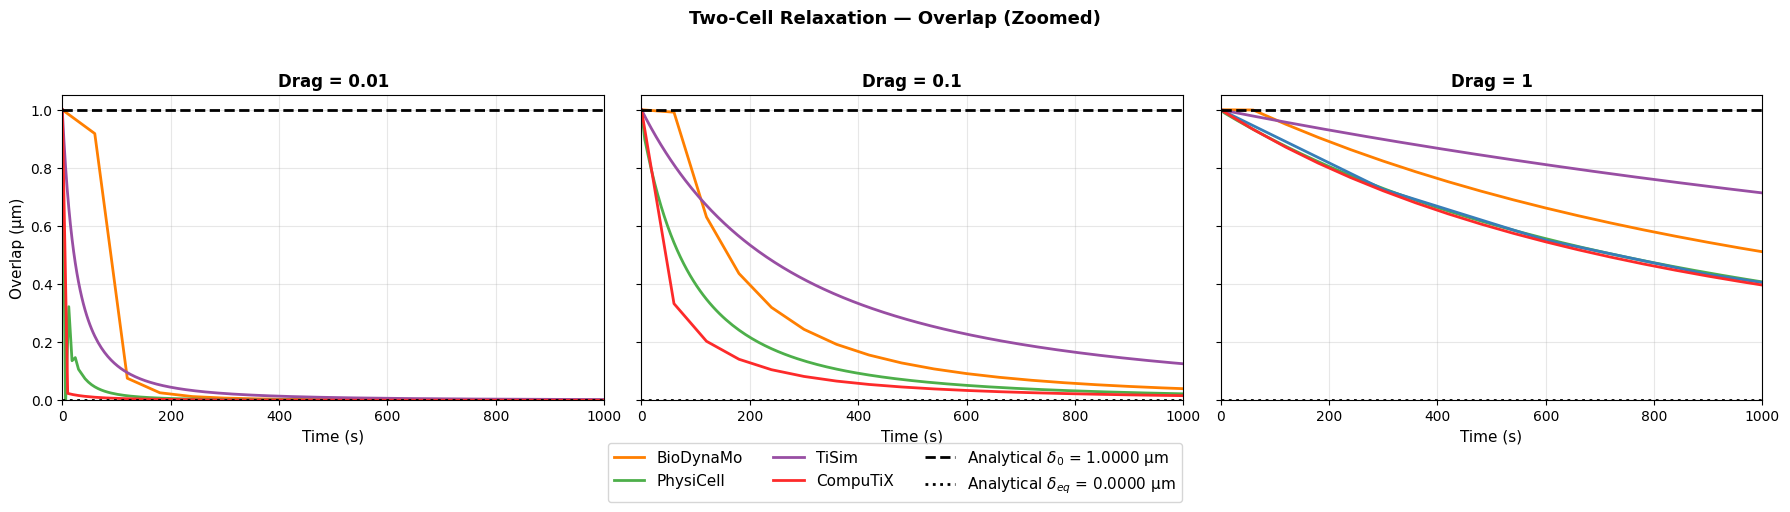

In [11]:
# ── One figure with three panels: one panel per drag value ──────────────

SIM_ORDER = ['BioDynaMo', 'PhysiCell', 'Chaste', 'TiSim', 'CompuTiX']
T_MAX = 1000  # seconds

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

fig.suptitle(
    'Two-Cell Relaxation — Overlap (Zoomed)',
    fontsize=13,
    fontweight='bold'
)

for ax, drag in zip(axes, DRAG_VALUES):

    for sim in SIM_ORDER:
        if sim not in data[drag]:
            continue

        d_plot = data[drag][sim]
        # d_plot = d[d['time'] <= T_MAX]

        kw = dict(
            color=COLORS[sim],
            lw=2,
            label=sim
        )

        ax.plot(
            d_plot['time'],
            d_plot['overlap'],
            **kw
        )

    # Analytical reference lines
    ax.axhline(
        delta_0_um,
        color='black',
        lw=2,
        ls='--',
        label=f'Analytical $\\delta_0$ = {delta_0_um:.4f} µm'
    )

    ax.axhline(
        delta_eq_um,
        color='black',
        lw=2,
        ls=':',
        label=f'Analytical $\\delta_{{eq}}$ = {delta_eq_um:.4f} µm'
    )

    ax.set_title(
        f'Drag = {drag}',
        fontsize=12,
        fontweight='bold'
    )

    ax.set_xlabel('Time (s)', fontsize=11)
    ax.set_xlim(0, T_MAX)
    ax.set_ylim(bottom=0)
    ax.grid(alpha=0.3)

axes[0].set_ylabel('Overlap (µm)', fontsize=11)

# Single legend for all panels
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.02),
    ncol=3,
    fontsize=11
)

plt.tight_layout(rect=[0, 0.08, 1, 0.95])

out = (
    ROOT
    / 'ResultAnalysis'
    / 'plots'
    / 'mechanics_pushing_extended_hertz'
    / f'mechanics_pushing_extended_hertz_drag_all_zoomed.png'
)

plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# ----- Analytical Solutions ------
# --- Force and ODE Definitions ---
def force_eHertz(delta):
    """Extended Hertz force as a function of overlap delta."""
    # Ensure delta does not become negative during numerical integration
    delta_pos = np.maximum(delta, 0)
    return (4/3) * E_tilde * np.sqrt(R_tilde) * (delta_pos**(1.5)) - np.pi * gamma * R_tilde

def ode_system(t, delta, gamma_drag):
    """Overdamped equation of motion: d(delta)/dt = -F / gamma_drag"""
    F = force_eHertz(delta[0])
    return [-F / gamma_drag]

# --- Physical Parameters ---
R1 = 1e-6  # Radius of cell 1 (m)
R2 = 1e-6  # Radius of cell 2 (m)
E1 = 450   # Young's modulus of cell 1 (Pa)
E2 = 450  # Young's modulus of cell 2 (Pa)
v1 = 0.4    # Poisson's ratio cell 1
v2 = 0.4    # Poisson's ratio cell 2
gamma = 8.56e-15 # Adhesion energy density (J/m^2)

# --- Calculated Effective Parameters ---
R_tilde = 1 / (1/R1 + 1/R2)
E_tilde = 1 / ((1 - v1**2)/E1 + (1 - v2**2)/E2)

# --- Initial Conditions and Time Domain ---
delta_0 = 1e-6  # Initial overlap: 1 micrometer (m)
t_span = (0, 18000)  # Time span (seconds)
t_eval = np.linspace(t_span[0], t_span[1], 2000)

/tmp/ipykernel_348161/1345174661.py:137: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


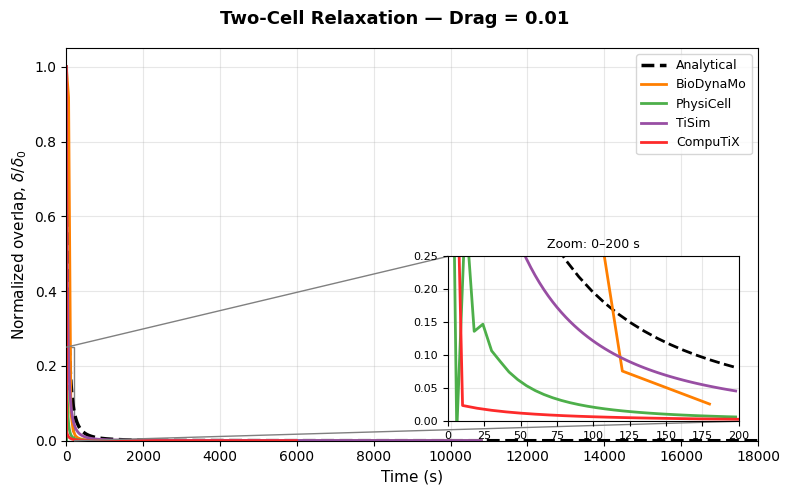

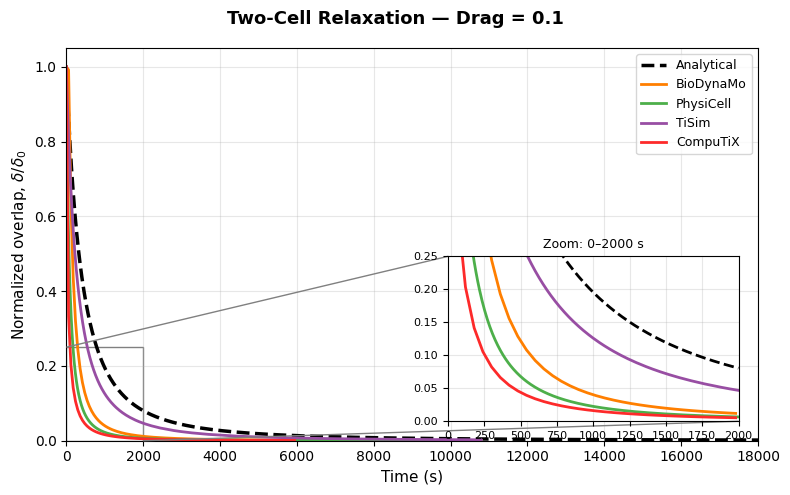

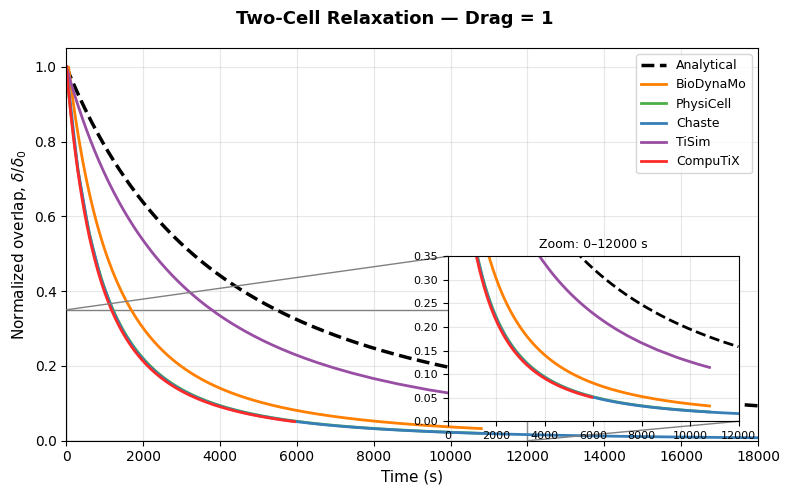

In [15]:

SIM_ORDER = ['BioDynaMo', 'PhysiCell', 'Chaste', 'TiSim', 'CompuTiX']

T_MAX = 18000  # full plot x limit

delta0 = delta_0_um
delta_eq = delta_eq_um

k_repulsion = 1.0  # change if needed

ZOOM_LIMITS = {
    0.01: (0, 200,   0, 0.25),
    0.1:  (0, 2000,  0, 0.25),
    1:    (0, 12000, 0, 0.35),
}

for drag in DRAG_VALUES:

    # --- Solver ---
    solution = solve_ivp(
        ode_system, 
        t_span, 
        [delta_0],
        args=(drag,), 
        t_eval=t_eval, 
        method='RK45',
        rtol=1e-8,   
        atol=1e-14,
)

    zoom_xmin, zoom_xmax, zoom_ymin, zoom_ymax = ZOOM_LIMITS[drag]

    fig, ax = plt.subplots(figsize=(8, 5))

    fig.suptitle(
        f'Two-Cell Relaxation — Drag = {drag}',
        fontsize=13,
        fontweight='bold'
    )

    time_ode = solution.t
    overlap_ode_norm = solution.y[0] / delta_0

    #delta_analytic = delta_eq + (delta0 - delta_eq) * np.exp(-t_analytic / tau)
    #delta_analytic_norm = delta_analytic / delta0

    ax.plot(
        time_ode,
        overlap_ode_norm,
        color='black',
        lw=2.5,
        ls='--',
        label='Analytical'
    )

    ax_zoom = inset_axes(
        ax,
        width="42%",
        height="42%",
        loc="lower right",
        borderpad=1.4
    )

    zoom_mask_ode = (time_ode >= zoom_xmin) & (time_ode <= zoom_xmax)
    ax_zoom.plot(
        time_ode[zoom_mask_ode],
        overlap_ode_norm[zoom_mask_ode],
        color='black',
        lw=2,
        ls='--'
    )

    for sim in SIM_ORDER:
        if sim not in data[drag]:
            continue

        d = data[drag][sim]

        time = np.asarray(d['time'])
        overlap = np.asarray(d['overlap'])

        mask = time <= T_MAX

        time_plot = time[mask]
        overlap_plot = overlap[mask] / delta0

        ax.plot(
            time_plot,
            overlap_plot,
            color=COLORS[sim],
            lw=2,
            label=sim
        )

        zoom_mask = (time >= zoom_xmin) & (time <= zoom_xmax)

        time_zoom = time[zoom_mask]
        overlap_zoom = overlap[zoom_mask] / delta0

        ax_zoom.plot(
            time_zoom,
            overlap_zoom,
            color=COLORS[sim],
            lw=2
        )

    ax.set_xlabel('Time (s)', fontsize=11)
    ax.set_ylabel(r'Normalized overlap, $\delta / \delta_0$', fontsize=11)
    ax.set_xlim(0, T_MAX)
    ax.set_ylim(0, 1.05)
    ax.grid(alpha=0.3)

    ax_zoom.set_xlim(zoom_xmin, zoom_xmax)
    ax_zoom.set_ylim(zoom_ymin, zoom_ymax)
    ax_zoom.grid(alpha=0.3)
    ax_zoom.set_title(
        f'Zoom: {zoom_xmin}–{zoom_xmax} s',
        fontsize=9
    )
    ax_zoom.tick_params(labelsize=8)

    mark_inset(
        ax,
        ax_zoom,
        loc1=2,
        loc2=4,
        fc="none",
        ec="0.5",
        lw=1
    )

    ax.legend(
        fontsize=9,
        frameon=True,
        loc='upper right'
    )

    plt.tight_layout()

    out = (
        ROOT
        / 'ResultAnalysis'
        / 'plots'
        / 'mechanics_pushing_extended_hertz'
        / f'mechanics_pushing_extended_hertz_drag_{drag}_with_drag_specific_zoom.png'
    )

    plt.savefig(out, dpi=300, bbox_inches='tight')
    plt.show()

In [12]:
final_errors = {}

for drag in DRAG_VALUES:

    final_errors[drag] = {}

    # analytical value at final time
    analytical_final = delta_eq_um

    for sim in SIM_ORDER:

        if sim not in data[drag]:
            continue

        d = data[drag][sim]

        overlap = np.asarray(d['overlap'])

        sim_final = overlap[-1]

        error = abs(sim_final - analytical_final)

        final_errors[drag][sim] = error

print(final_errors)

{0.01: {'BioDynaMo': np.float64(9.758075376008014e-06), 'PhysiCell': np.float64(3.137495028299029e-05), 'TiSim': np.float64(0.0005197580753762405), 'CompuTiX': np.float64(3.7580753769457035e-06)}, 0.1: {'BioDynaMo': np.float64(0.00046975807537635704), 'PhysiCell': np.float64(0.0002599314124427866), 'TiSim': np.float64(0.002509758075377287), 'CompuTiX': np.float64(0.0007437580753755763)}, 1: {'BioDynaMo': np.float64(0.03246975807537639), 'PhysiCell': np.float64(0.019835130938747187), 'Chaste': np.float64(0.007923758075377317), 'TiSim': np.float64(0.11427975807537721), 'CompuTiX': np.float64(0.050962758075375814)}}


In [17]:
errors = np.zeros((len(DRAG_VALUES), len(SIM_ORDER)))

for i, drag in enumerate(DRAG_VALUES):

    for j, sim in enumerate(SIM_ORDER):

        if sim not in data[drag]:
            errors[i, j] = np.nan
            continue

        overlap = np.asarray(data[drag][sim]['overlap'])
        # relative final error in percentage
        errors[i, j] = (100 * abs(overlap[-1] - delta_eq_um)/ delta_0_um
)

print(errors)

[[9.75807538e-04 3.13749503e-03            nan 5.19758075e-02
  3.75807538e-04]
 [4.69758075e-02 2.59931412e-02            nan 2.50975808e-01
  7.43758075e-02]
 [3.24697581e+00 1.98351309e+00 7.92375808e-01 1.14279758e+01
  5.09627581e+00]]


In [18]:
rows = []

for drag in DRAG_VALUES:

    analytical_final = delta_eq_um

    for sim in SIM_ORDER:

        if sim not in data[drag]:
            continue

        overlap = np.asarray(data[drag][sim]['overlap'])

        sim_final = overlap[-1]

        error = 100 * abs(overlap[-1] - delta_eq_um)/ delta_0_um


        rows.append({
            'drag': drag,
            'simulator': sim,
            'final_overlap': sim_final,
            'analytical_overlap': analytical_final,
            'absolute_error': error
        })

errors_df = pd.DataFrame(rows)

print(errors_df)

    drag  simulator  final_overlap  analytical_overlap  absolute_error
0   0.01  BioDynaMo       0.000010        2.419246e-07        0.000976
1   0.01  PhysiCell       0.000032        2.419246e-07        0.003137
2   0.01      TiSim       0.000520        2.419246e-07        0.051976
3   0.01   CompuTiX       0.000004        2.419246e-07        0.000376
4   0.10  BioDynaMo       0.000470        2.419246e-07        0.046976
5   0.10  PhysiCell       0.000260        2.419246e-07        0.025993
6   0.10      TiSim       0.002510        2.419246e-07        0.250976
7   0.10   CompuTiX       0.000744        2.419246e-07        0.074376
8   1.00  BioDynaMo       0.032470        2.419246e-07        3.246976
9   1.00  PhysiCell       0.019835        2.419246e-07        1.983513
10  1.00     Chaste       0.007924        2.419246e-07        0.792376
11  1.00      TiSim       0.114280        2.419246e-07       11.427976
12  1.00   CompuTiX       0.050963        2.419246e-07        5.096276
